In [1]:
import torch 
from torch import nn, Tensor

import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

In [2]:
class DDPM(nn.Module):
    def __init__(self, dim: int = 2, h: int = 64, n_steps: int = 100):
        super().__init__()
        self.n_steps = n_steps
        self.betas = torch.linspace(1e-4, 0.02, n_steps)
        self.alphas = 1.0 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)
        
        self.net = nn.Sequential(
            nn.Linear(dim + 1, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, h), nn.ELU(),
            nn.Linear(h, dim)
        )
    
    def forward(self, t: Tensor, x_t: Tensor) -> Tensor:
        t = t.view(-1, 1)
        return self.net(torch.cat((t, x_t), dim=-1))
    
    def sample_step(self, x_t: Tensor, t: int) -> Tensor:
        noise = torch.randn_like(x_t)
        alpha_t = self.alphas[t]
        alpha_bar_t = self.alpha_bars[t]
        coeff = (1 - alpha_t) / torch.sqrt(1 - alpha_bar_t)
        t_tensor = torch.full((x_t.shape[0],), t / self.n_steps, device=x_t.device)
        predicted_noise = self(t_tensor, x_t)
        x_t = (x_t - coeff * predicted_noise) / torch.sqrt(alpha_t)
        return x_t + torch.sqrt(1 - alpha_t) * noise if t > 0 else x_t


# Training

In [3]:
ddpm = DDPM()
optimizer = torch.optim.Adam(ddpm.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

for _ in range(10000):
    x_0 = Tensor(make_moons(256, noise=0.05)[0])
    t = torch.randint(0, ddpm.n_steps, (x_0.shape[0],))
    noise = torch.randn_like(x_0)
    
    alpha_bar_t = ddpm.alpha_bars[t].view(-1, 1)
    x_t = torch.sqrt(alpha_bar_t) * x_0 + torch.sqrt(1 - alpha_bar_t) * noise
    
    optimizer.zero_grad()
    t_normalized = t / ddpm.n_steps
    predicted_noise = ddpm(t_normalized, x_t)
    loss = loss_fn(predicted_noise, noise)
    loss.backward()
    optimizer.step()

# Sampling

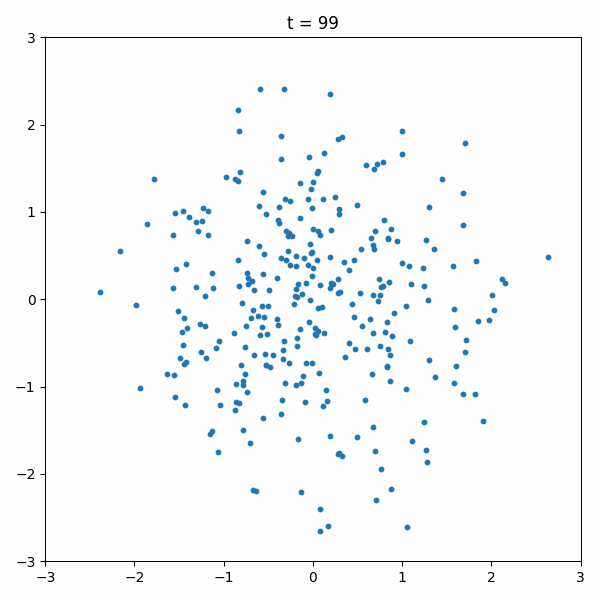

In [4]:
from matplotlib.animation import FuncAnimation
from IPython.display import Image
%matplotlib inline

# Sampling Animation
x = torch.randn(300, 2)
n_steps = 100
time_steps = torch.linspace(ddpm.n_steps - 1, 0, n_steps, dtype=torch.long)

fig, ax = plt.subplots(figsize=(6, 6))
ax.set_xlim(-3.0, 3.0)
ax.set_ylim(-3.0, 3.0)
scatter = ax.scatter(x.detach()[:, 0], x.detach()[:, 1], s=10)
title = ax.set_title(f't = {time_steps[0]:.0f}')

def update(frame):
    global x
    x = ddpm.sample_step(x, time_steps[frame])
    scatter.set_offsets(x.detach().numpy())
    title.set_text(f't = {time_steps[frame]:.0f}')
    return scatter, title

ani = FuncAnimation(fig, update, frames=range(n_steps), interval=100, blit=True)
plt.tight_layout()
ani.save('ddpm_moons_animation.gif', writer='pillow', fps=10)
plt.close()
Image(filename='ddpm_moons_animation.gif')